In [ ]:
import pandas as pd

df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

Dataset 1 Shape: (768, 7)
Dataset 2 Shape: (267, 9)


In [ ]:
print("Dataset 1 Columns:")
print(df1.columns)

print("\nDataset 2 Columns:")
print(df2.columns)

Dataset 1 Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Dataset 2 Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [ ]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df1.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
df1 = df1.dropna()

print("New Shape:", df1.shape)

New Shape: (740, 7)


In [ ]:
df1[' Date'] = pd.to_datetime(df1[' Date'])

print(df1.dtypes)

Region                                              object
 Date                                       datetime64[ns]
 Frequency                                          object
 Estimated Unemployment Rate (%)                   float64
 Estimated Employed                                float64
 Estimated Labour Participation Rate (%)           float64
Area                                                object
dtype: object


/tmp/ipykernel_3816/3993146280.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1[' Date'] = pd.to_datetime(df1[' Date'])


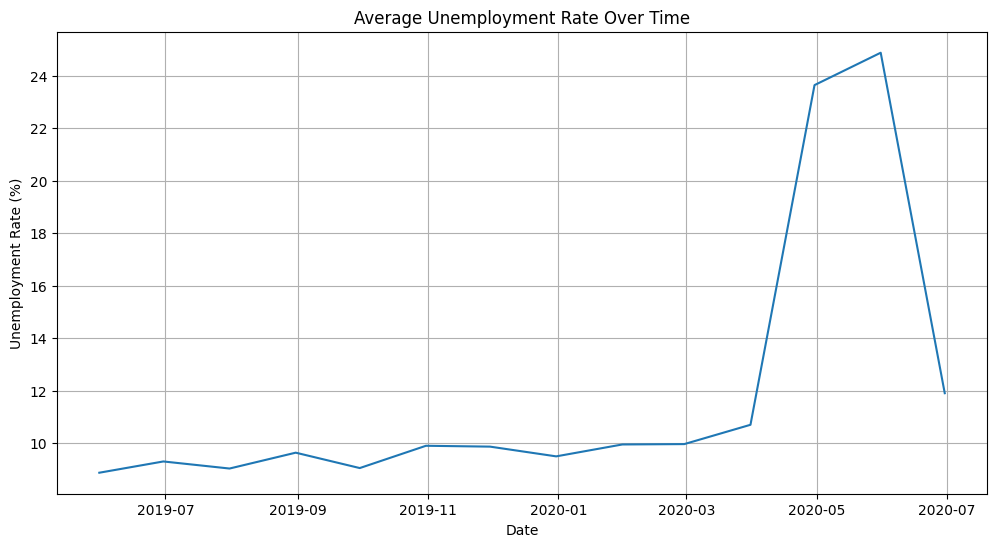

In [ ]:
import matplotlib.pyplot as plt

avg_unemployment = df1.groupby(' Date')[' Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))
plt.plot(avg_unemployment.index, avg_unemployment.values)

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()


In [ ]:
df1.columns = df1.columns.str.strip()

print(df1.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [ ]:
top_states = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print(top_states.head(10))

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


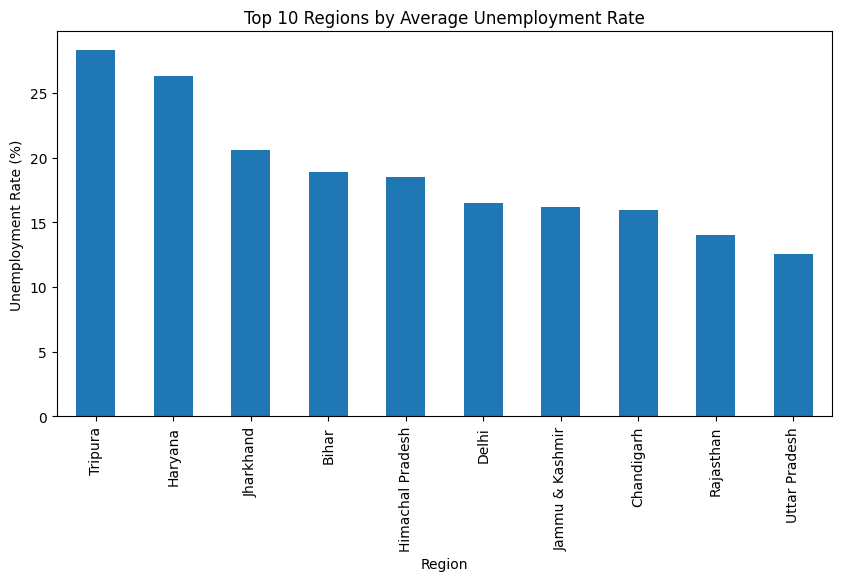

In [ ]:
import matplotlib.pyplot as plt

top_states.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.show()


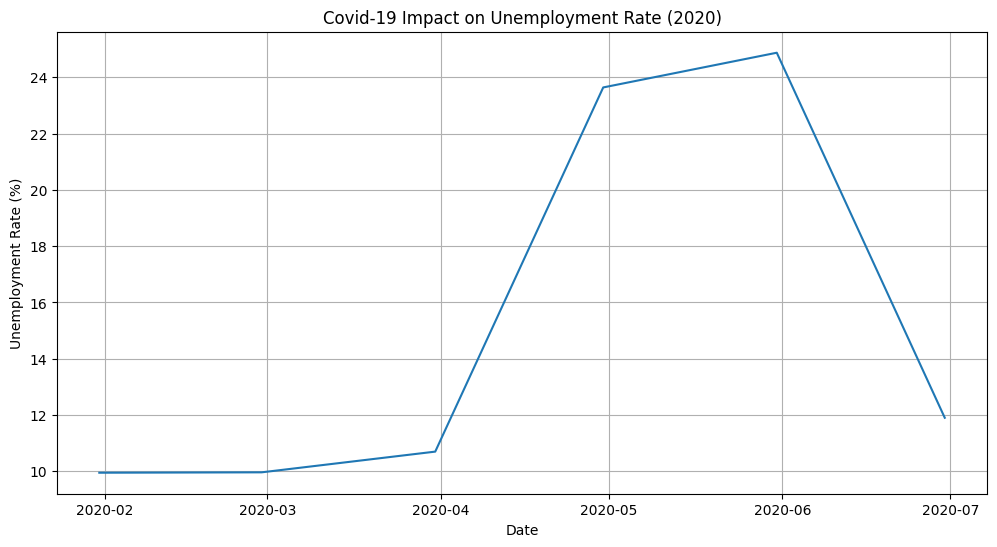

In [ ]:
covid_data = df1[df1['Date'] >= '2020-01-01']

covid_trend = covid_data.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))
plt.plot(covid_trend.index, covid_trend.values)

plt.title("Covid-19 Impact on Unemployment Rate (2020)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()